# Operator factorization ablation: factorized vs joint latent map

The default networked operator (one-tap degree $P=1$)

$$
I \otimes K_{\mathrm{self}} + \hat{A} \otimes K_{\mathrm{nbr}}
$$

ties parameters across nodes. This notebook first measures what that tying
costs on a small path-diffusion surrogate: rollout mean squared error (MSE),
trainable (or fitted) parameter count, and spectral agreement versus an
**unconstrained** joint map on the same flattened latents. A later section
retrains hop-matched models at $P \in \{0,1,2\}$ on the same surrogate.
Results are for $N=4$, $d=2$ only — do not generalize beyond this setup.
Raising $P$ is **not** claimed to explain the historical joint least-squares
gap.


## Setup


In [1]:
import os
import warnings

from tqdm.std import TqdmExperimentalWarning, TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch

import koopman_graph
from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel, compute_spectrum
from koopman_graph.analysis import dynamical_similarity
from koopman_graph.baselines.base import fit_row_operator
from koopman_graph.datasets.synthetic import SyntheticDynamicGraphBenchmark
from koopman_graph.nn import ReceptiveFieldMismatchWarning

SEED = 0
N = 4
FEATURES = 2
LATENT = 2  # joint state dim = N * LATENT = 8
STEPS = 8
EPOCHS = 80  # historical one-tap vs joint-LS protocol
EPOCHS_P = 40  # hop-matched P-arm only; not comparable to EPOCHS
LR = 5e-3
torch.manual_seed(SEED)

DIFFUSION = dict(
    in_channels=FEATURES,
    topology="path",
    diffusion_rate=0.35,
    decay_rate=0.92,
    noise_std=0.0,
    initial_state="ones",
)

print(
    f"koopman_graph {koopman_graph.__version__}; "
    f"torch {torch.__version__}; joint state dim = {N * LATENT}"
)


koopman_graph 0.15.0; torch 2.13.0; joint state dim = 8


## Motivation and background

Factorized graph Koopman operators keep shared $d \times d$ blocks and rebuild
an effective $(Nd) \times (Nd)$ map through the adjacency
([Li et al., 2020](https://openreview.net/forum?id=H1ldzA4tPr)). At the
factory default $P=1$ those blocks are $K_{\mathrm{self}}$ and
$K_{\mathrm{nbr}}$ ($2d^2$ free parameters in symmetric adjacency mode).
Opt-in $P>1$ adds globally shared extra hops, for $(P+1)d^2$ factor
parameters. Every node still shares the same blocks; coupling enters only
through powers of $\hat{A}$.

An unconstrained joint operator on flattened latents has $(Nd)^2$ free entries
and can represent couplings the Kronecker form cannot. At small $N$ we can fit
that joint map by least squares on encoded trajectories and ask how much
multi-step accuracy and spectral structure the **one-tap** factorization leaves
on the table — without claiming the gap holds for large graphs, other systems,
or higher $P$.


## Minimal example: shared encoder/decoder, two latent maps

1. Train `koopman="graph"` end-to-end with **explicit**
   `koopman_filter_degree=1` (the factory default) and a two-layer GCN codec.
   Encoder hops (2) exceed operator hops (1), so `fit` emits
   `ReceptiveFieldMismatchWarning`; training still proceeds.
2. Freeze the codec; encode the training trajectory.
3. Fit an unrestricted $K_{\mathrm{joint}} \in \mathbb{R}^{Nd \times Nd}$ with
   `fit_row_operator` (row convention $z_{t+1} = z_t K^{\top}$).
4. Roll out both maps from the same holdout origin and decode with the same
   decoder.

This historical protocol uses 80 epochs. Do not retune it when reading the
later $P$-arm (40 epochs, hop-matched codec).


In [2]:
train = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=N, num_timesteps=50, seed=0, **DIFFUSION
)
hold = SyntheticDynamicGraphBenchmark.generate(
    num_nodes=N, num_timesteps=20, seed=1, **DIFFUSION
)
edge_index = train[0].edge_index

torch.manual_seed(SEED)
graph_model = GraphKoopmanModel(
    GNNEncoder(FEATURES, 32, LATENT, num_layers=2),
    GNNDecoder(LATENT, 32, FEATURES, num_layers=2),
    latent_dim=LATENT,
    time_step=1.0,
    koopman="graph",
    koopman_filter_degree=1,
)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always", ReceptiveFieldMismatchWarning)
    _ = graph_model.fit(train, epochs=EPOCHS, lr=LR, device="cpu")
hop_warned = any(
    issubclass(w.category, ReceptiveFieldMismatchWarning) for w in caught
)
graph_model.eval()

with torch.no_grad():
    Z_train = torch.stack(
        [
            graph_model.encode_at(train, t).reshape(-1)
            for t in range(train.num_timesteps)
        ]
    )
K_joint = fit_row_operator(Z_train[:-1], Z_train[1:], rank=None)

print("K_joint shape:", tuple(K_joint.shape))
print(
    "factor params:",
    sum(p.numel() for p in graph_model.koopman.parameters() if p.requires_grad),
)
print("joint fitted entries:", int(K_joint.numel()))
print("receptive-field mismatch warning (2-layer encoder vs P=1):", hop_warned)


K_joint shape: (8, 8)
factor params: 8
joint fitted entries: 64
receptive-field mismatch warning (2-layer encoder vs P=1): True


## Progressive deep dive: rollout, counts, spectra

Parameter counts compare the **trainable** one-tap factorized blocks to the
**fitted** joint matrix (the joint arm is not end-to-end trained). Spectral
agreement uses `dynamical_similarity` between the factorized effective spectrum
and `compute_spectrum(K_joint)`.


In [3]:
def rollout_mse_graph(model, sequence, steps: int = STEPS) -> float:
    preds = model.predict(sequence[0], steps)
    errs = [
        torch.mean((preds[h].x - sequence[h + 1].x) ** 2) for h in range(steps)
    ]
    return float(torch.stack(errs).mean().item())


def rollout_mse_joint(model, K, sequence, steps: int = STEPS) -> float:
    with torch.no_grad():
        z = model.encode(sequence[0]).reshape(-1)
        errs = []
        for h in range(steps):
            z = z @ K.T
            x_hat = model.decoder(z.reshape(N, LATENT), edge_index, None)
            errs.append(torch.mean((x_hat - sequence[h + 1].x) ** 2))
    return float(torch.stack(errs).mean().item())


mse_factor = rollout_mse_graph(graph_model, hold)
mse_joint = rollout_mse_joint(graph_model, K_joint, hold)
n_factor = sum(
    p.numel() for p in graph_model.koopman.parameters() if p.requires_grad
)
n_joint = int(K_joint.numel())

spec_factor = graph_model.spectrum(edge_index=edge_index, num_nodes=N)
spec_joint = compute_spectrum(K_joint.detach(), graph_model.time_step)
spectrum_distance = float(dynamical_similarity(spec_factor, spec_joint).detach())

K_eff = graph_model.koopman.effective_matrix(edge_index, N)
print(f"factorized rollout MSE: {mse_factor:.4f}")
print(f"joint LS rollout MSE:   {mse_joint:.4f}")
print(f"parameter count:        factor={n_factor}  joint={n_joint}")
print(f"spectral distance:      {spectrum_distance:.4f}")
print(f"effective K shape:      {tuple(K_eff.shape)}")


factorized rollout MSE: 0.7075
joint LS rollout MSE:   0.0185
parameter count:        factor=8  joint=64
spectral distance:      0.5919
effective K shape:      (8, 8)


## Results (historical one-tap protocol)

Bars: multi-step MSE (left) and operator degrees of freedom (right) for the
**80-epoch**, $P=1$, two-layer-encoder run. Expect the joint LS fit on frozen
latents to achieve lower rollout error at an $(Nd)^2 / (2d^2)$ parameter
premium ($64/8 = 8\times$ here). Look for a large left-bar gap together with
the $8\times$ right-bar DoF ratio. The printed spectral distance (default
Wasserstein comparison via `dynamical_similarity`) quantifies disagreement
between the factorized effective spectrum and the joint spectrum — not a claim
about ResDMD residuals, and not a claim that encoder hop order caused the gap.


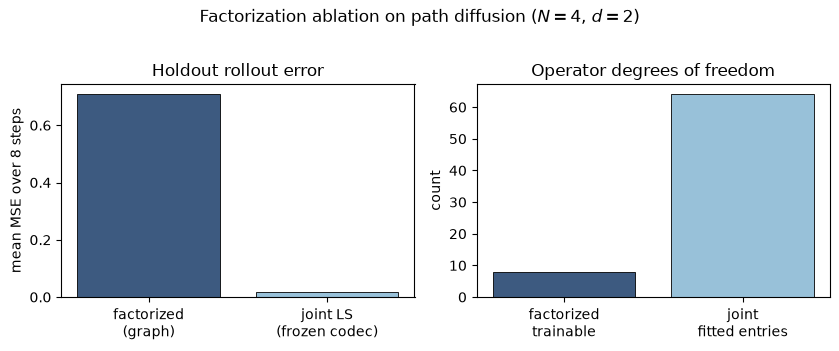

Measured ratio joint/factor MSE: 0.0261; param ratio joint/factor: 8.0; spectral distance: 0.5919


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.4))

axes[0].bar(
    ["factorized\n(graph)", "joint LS\n(frozen codec)"],
    [mse_factor, mse_joint],
    color=["#3d5a80", "#98c1d9"],
    edgecolor="black",
    linewidth=0.6,
)
axes[0].set_ylabel(f"mean MSE over {STEPS} steps")
axes[0].set_title("Holdout rollout error")

axes[1].bar(
    ["factorized\ntrainable", "joint\nfitted entries"],
    [n_factor, n_joint],
    color=["#3d5a80", "#98c1d9"],
    edgecolor="black",
    linewidth=0.6,
)
axes[1].set_ylabel("count")
axes[1].set_title("Operator degrees of freedom")
fig.suptitle(
    f"Factorization ablation on path diffusion ($N={N}$, $d={LATENT}$)",
    y=1.02,
)
fig.tight_layout()
plt.show()

print(
    f"Measured ratio joint/factor MSE: {mse_joint / max(mse_factor, 1e-12):.4f}; "
    f"param ratio joint/factor: {n_joint / n_factor:.1f}; "
    f"spectral distance: {spectrum_distance:.4f}"
)


## Interpretation / discussion

On this seeded path-diffusion surrogate with a shared GNN codec, unrestricted
least-squares on flattened latents substantially reduces multi-step MSE relative
to the trained **one-tap** ($P=1$) factorized operator, at an $8\times$
increase in operator degrees of freedom ($64$ vs $8$). Spectral distance
between the effective factorized operator and $K_{\mathrm{joint}}$ is nonzero,
so the two maps are not merely reparameterizations of each other.

The historical factorized arm used a two-layer encoder (two hops) with a
one-hop Koopman factor. Encoder neighborhood mixing does not compensate for a
one-hop $K$; the warning above records that mismatch. That observation does
**not** identify hop order as the cause of the MSE gap: the joint arm is a
post-hoc linear fit on frozen encodings, not a second end-to-end trained
model, and the factorized arm carries whatever the encoder–operator–decoder
training achieved in $80$ epochs.

Do not extrapolate the numerical gap to larger $N$, other topologies, higher
$P$, or systems where the Kronecker structure matches the physics. The next
section retrains hop-matched $P \in \{0,1,2\}$ models for $40$ epochs on the
same surrogate; those numbers are a different protocol.


## Degree-$P$ ablation (hop-matched encoder)

Factory `koopman_filter_degree` stays $1$; here $P$ is passed **explicitly**.
For $P \ge 1$ the GCN codec uses `num_layers=P` so encoder hops match the
monomial operator radius. A GCN cannot use zero layers, so $P=0$ (self term
only) is trained with `num_layers=1` and is expected to warn.

Each arm is trained for **40 epochs** from the same seed on the same
path-diffusion data as the historical comparison. That is **not** the
80-epoch historical protocol: do not treat a $P=2$ win on this seed as the
cause of the joint-LS gap, and do not splice these MSE values onto the
previous figure.


In [5]:
def _hop_warned(caught):
    return any(
        issubclass(w.category, ReceptiveFieldMismatchWarning) for w in caught
    )


def _allocated_params(model):
    return sum(p.numel() for p in model.koopman.parameters() if p.requires_grad)


P_VALUES = (0, 1, 2)
p_rows = []

for degree in P_VALUES:
    torch.manual_seed(SEED)
    n_layers = max(degree, 1)
    model_p = GraphKoopmanModel(
        GNNEncoder(FEATURES, 32, LATENT, num_layers=n_layers),
        GNNDecoder(LATENT, 32, FEATURES, num_layers=n_layers),
        latent_dim=LATENT,
        time_step=1.0,
        koopman="graph",
        koopman_filter_degree=degree,
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ReceptiveFieldMismatchWarning)
        _ = model_p.fit(train, epochs=EPOCHS_P, lr=LR, device="cpu")
    model_p.eval()
    mse_p = rollout_mse_graph(model_p, hold)
    allocated = _allocated_params(model_p)
    active = (degree + 1) * LATENT * LATENT
    warned_p = _hop_warned(caught)
    p_rows.append((degree, n_layers, active, allocated, mse_p, warned_p))
    print(
        f"P={degree}: encoder_layers={n_layers}  active_factors={active}  "
        f"allocated_params={allocated}  holdout_MSE={mse_p:.4f}  "
        f"hop_warning={warned_p}"
    )

mse_by_p = {row[0]: row[4] for row in p_rows}
if mse_by_p[2] < mse_by_p[1]:
    print(
        "On this seed, hop-matched P=2 has lower hold-out MSE than P=1. "
        "That is not evidence that hop order caused the historical joint-LS "
        "gap (different epoch count, different encoder depth, and the joint "
        "arm is post-hoc least squares)."
    )
else:
    print(
        "On this seed, hop-matched P=2 did not beat P=1 on hold-out MSE. "
        "Either outcome still does not attribute the historical joint-LS gap "
        "to hop order."
    )


P=0: encoder_layers=1  active_factors=4  allocated_params=8  holdout_MSE=1.0900  hop_warning=True
P=1: encoder_layers=1  active_factors=8  allocated_params=8  holdout_MSE=3.3018  hop_warning=False
P=2: encoder_layers=2  active_factors=12  allocated_params=12  holdout_MSE=1.3187  hop_warning=False
On this seed, hop-matched P=2 has lower hold-out MSE than P=1. That is not evidence that hop order caused the historical joint-LS gap (different epoch count, different encoder depth, and the joint arm is post-hoc least squares).


## Results (hop-matched $P$ arm)

Bars below use the **40-epoch** hop-matched protocol. Active factors in
$K_{\mathrm{eff}}$ are $(P+1)d^2$ ($4$, $8$, $12$). At $P=0$ the unused
$K_{\mathrm{nbr}}$ block is still an allocated `nn.Parameter` (8 entries);
the map itself is self-only. The $P=0$ fit is allowed to warn (encoder hops
$1$ vs operator hops $0$). Compare $P$ values **within this figure only**.


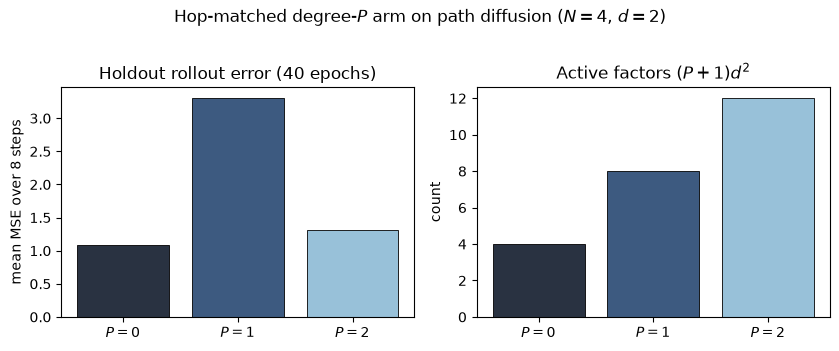

In [6]:
fig_p, axes_p = plt.subplots(1, 2, figsize=(8.5, 3.4))
labels_p = [f"$P={row[0]}$" for row in p_rows]
mses_p = [row[4] for row in p_rows]
active_p = [row[2] for row in p_rows]

axes_p[0].bar(
    labels_p,
    mses_p,
    color=["#293241", "#3d5a80", "#98c1d9"],
    edgecolor="black",
    linewidth=0.6,
)
axes_p[0].set_ylabel(f"mean MSE over {STEPS} steps")
axes_p[0].set_title(f"Holdout rollout error ({EPOCHS_P} epochs)")

axes_p[1].bar(
    labels_p,
    active_p,
    color=["#293241", "#3d5a80", "#98c1d9"],
    edgecolor="black",
    linewidth=0.6,
)
axes_p[1].set_ylabel("count")
axes_p[1].set_title("Active factors $(P+1)d^2$")
fig_p.suptitle(
    f"Hop-matched degree-$P$ arm on path diffusion ($N={N}$, $d={LATENT}$)",
    y=1.02,
)
fig_p.tight_layout()
plt.show()


## Interpretation of the $P$ arm

These three fits share the surrogate, seed, and learning rate with the
historical comparison, but not the epoch count or encoder depth. $P=0$ cannot
hop-match a GCN (`num_layers` is at least $1$), and it still allocates an
unused neighbor block. If hop-matched $P=2$ beats $P=1$ on this seed, report
that number and stop there: it is one surrogate, one seed, and a shorter
schedule.

The historical ~$0.71$ versus ~$0.019$ hold-out MSE gap (8 factor parameters
versus 64 joint entries) remains a **one-tap versus post-hoc joint LS**
result. This arm does not rewrite those figures and does not treat hop order
as their cause. Algebraic Kronecker-versus-dense spectrum for $P=2$ is in
`49_multi_hop_factorization.ipynb`, not a forecasting contest.


## Takeaways

- Factorization buys a $(P+1)d^2$ **active** operator budget and
  topology-conditioned advance; the unconstrained latent map needs
  $(Nd)^2$ entries. Default $P=1$ is $2d^2$. At $P=0$, unused $K_{\mathrm{nbr}}$
  remains allocated.
- On this $N=4$, $d=2$ diffusion surrogate, joint LS on frozen latents
  achieved much lower holdout MSE than the trained one-tap factorized
  operator (80 epochs, two-layer encoder), with nontrivial spectral distance
  between the two maps.
- A hop-matched $P \in \{0,1,2\}$ retrain (40 epochs) is a separate protocol.
  Encoder mixing does not substitute for raising $P$; $P=0$ cannot hop-match
  a GCN. Neither protocol attributes the historical MSE gap to hop order.
- Report both error **and** parameter count; a lower joint error alone is not a
  reason to abandon factorization when $N$ is large.
- Rebuild or refute this ablation before claiming the factorized form is
  "essentially as expressive" on a new domain.


## Further reading

- Package API: `GraphKoopmanOperator.effective_matrix`, `GraphKoopmanModel`
  with `koopman="graph"` and explicit `koopman_filter_degree`,
  `fit_row_operator`, `compute_spectrum`, `dynamical_similarity`,
  `ReceptiveFieldMismatchWarning`
- Related notebooks: `49_multi_hop_factorization.ipynb` (Kronecker vs dense
  $P=2$ spectrum; hop warning), `37_cross_topology_transfer.ipynb`
  (cross-$N$ transfer), `35_symmetry_adapted_operator.ipynb` (orbit ties),
  `29_large_graph_block_diagonal.ipynb` ($N \cdot d$ cost)
- Li, Y., He, H., Wu, J., Katabi, D., & Torralba, A. (2020). Learning
  compositional Koopman operators for model-based control.
  *International Conference on Learning Representations (ICLR)*.
  https://openreview.net/forum?id=H1ldzA4tPr
